# Eigenmode under uncertainty (spline & RF gun)

> **Uncertainty quantification plugs into every analysis.** In cavsim2d, a run is deterministic — one geometry, one answer — until you add a `uq_config`. With it, the analysis is evaluated over a small Stroud-3 quadrature of the uncertain geometry and returns a **distribution** (mean and standard deviation) instead of a single number. The *same* pattern works for eigenmode, tuning (robust tuning), wakefield, and optimisation (robust optimisation) — only multipacting does not yet take a `uq_config`.

These advanced examples deliberately span several cavity types (spline, RF gun, flat-top, elliptical, pillbox) — a good stress test of the model-agnostic machinery.

Here we propagate a geometry tolerance through the **eigenmode** solve for two non-elliptical cavities.

In [1]:
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cavsim2d import Study, SplineCavity, RFGun
from cavsim2d.utils.style import apply_style

apply_style()

## 1. A spline cavity — uncertainty on a control point

A `SplineCavity` is parameterised by Bézier control points, so its uncertain variables are point *coordinates* (here the radius of `p3`, the equator control point). A 2% spread on it moves the frequency and R/Q.

In [2]:
geom = {'p0': [0, 35], 'p1': [0, 70], 'p2': [30, 103],
        'p3': [85, 103], 'p4': [115, 70], 'p5': [115, 35]}
cavs = Study(os.path.join(tempfile.mkdtemp(), 'spline_uq'))
cavs.add_cavity([SplineCavity({'geometry': dict(geom)}, kind='Bezier')], ['SPLINE'])

cavs.run_eigenmode({
    'processes': 1, 'rerun': True, 'boundary_conditions': 'mm',
    'uq_config': {
        'variables': ['p3_r'],
        'objectives': ['monopole:freq [MHz]', 'monopole:R/Q [Ohm]'],
        'method': ['stroud3'], 'delta': [0.02], 'processes': 1,
    },
})
res = cavs.uq_fm_results['SPLINE']
pd.DataFrame({q.split(':', 1)[-1]: {'mean': v['expe'][0], 'std': v['stdDev'][0]}
             for q, v in res.items()}).T.round(4)

,mean,std
freq [MHz],1534.0516,0.0578
R/Q [Ohm],103.4231,0.0006


## 2. An RF gun — uncertainty on a wall radius

The exact same call, a different model: a 2% spread on the gun's `R6` wall radius. Nothing about the UQ setup is elliptical-specific.

In [3]:
gun = {'geometry': {'y1': 1.5e-2, 'R2': 3e-2, 'T2': np.deg2rad(45), 'L3': 24e-2,
                    'R4': 5e-2, 'L5': 11e-2, 'R6': 6e-2, 'L7': 19e-2, 'R8': 4e-2,
                    'T9': np.deg2rad(8), 'R10': 3e-2, 'T10': np.deg2rad(40),
                    'L11': 5e-2, 'R12': 3e-2, 'L13': 3e-2, 'R14': 3e-2, 'x': 1e-2}}
cavs_g = Study(os.path.join(tempfile.mkdtemp(), 'gun_uq'))
cavs_g.add_cavity([RFGun(gun)], ['GUN'])

cavs_g.run_eigenmode({
    'processes': 1, 'rerun': True, 'boundary_conditions': 'mm',
    'uq_config': {
        'variables': ['R6'],
        'objectives': ['monopole:freq [MHz]', 'monopole:R/Q [Ohm]'],
        'method': ['stroud3'], 'delta': [0.02], 'processes': 1,
    },
})
res_g = cavs_g.uq_fm_results['GUN']
pd.DataFrame({q.split(':', 1)[-1]: {'mean': v['expe'][0], 'std': v['stdDev'][0]}
             for q, v in res_g.items()}).T.round(4)

,mean,std
freq [MHz],212.6273,0.2061
R/Q [Ohm],132.7171,14.4280


## 3. The spread, at a glance

`eigenmode.plot_fm_scatter(uq=True)` shows each figure of merit as a mean with a $\pm1\sigma$ error bar and the nominal design point — the built-in UQ comparison plot.

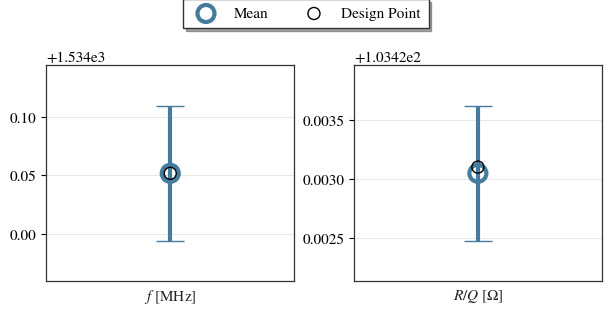

{'monopole:freq [MHz]': <Axes: label='monopole:freq [MHz]', xlabel='$f$ [MHz]'>,
 'monopole:R/Q [Ohm]': <Axes: label='monopole:R/Q [Ohm]', xlabel='$R/Q ~\\mathrm{[\\Omega]}$'>}

In [4]:
cavs.eigenmode.plot_fm_scatter(uq=True, qois=['freq', 'R/Q'])

See also: [robust tuning](robust_tuning.ipynb) and [robust optimisation](robust_optimisation.ipynb).